# Preprocessing & Modeling — Sistem Rekomendasi Wisata Bandung

**Nama**: Mira Aldina  
**NIM**: 41037006221007  
**Prodi**: Teknik Informatika - UNINUS  

**Metode**: Content-Based Filtering dengan TF-IDF + Cosine Similarity  
**Dataset**: 331 destinasi wisata Bandung Raya (setelah hapus duplikat)

## Tahapan:
1. Load dataset CSV
2. Text Preprocessing (Case Folding, Cleaning, Tokenization, Stopword Removal, Stemming)
3. Pembobotan TF-IDF
4. Perhitungan Cosine Similarity
5. Test rekomendasi
6. Save model (.pkl) untuk dipakai backend Flask

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import re
import pickle
import os
import sys
import subprocess
from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

try:
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
except ModuleNotFoundError:
    print('Library Sastrawi belum terinstall. Menginstall Sastrawi...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'Sastrawi'])
    from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
    from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

print('Semua library berhasil di-import')


Semua library berhasil di-import


## 2. Load Dataset

In [2]:
def repair_wisata_csv(path):
    """
    Memperbaiki CSV yang deskripsinya berisi koma tetapi tidak dibungkus tanda kutip.
    Format akhir: Place_Id, Place_Name, Description, Category, City.
    """
    raw_text = Path(path).read_text(encoding='utf-8-sig')
    lines = raw_text.splitlines()
    body = '\n'.join(lines[1:])

    # Perbaiki kasus ada 2 baris destinasi yang menempel tanpa newline.
    body = re.sub(r'(Kota Bandung|Kabupaten Bandung|Kota Cimahi|Bandung Barat)(?=\d+,)', r'\1\n', body)

    known_names_with_commas = {
        209: 'Sapulidi Cafe, Resort & Gallery',
        211: 'Lereng Anteng, Dago Bakery',
    }

    rows = []
    for line in body.splitlines():
        line = line.strip()
        if not line:
            continue

        first_comma = line.find(',')
        place_id = int(line[:first_comma].strip())
        rest = line[first_comma + 1:].strip()

        # Category dan City berada di 2 kolom terakhir.
        main, category, city = [part.strip() for part in rest.rsplit(',', 2)]

        if place_id in known_names_with_commas:
            place_name = known_names_with_commas[place_id]
            description = main.replace(place_name, '', 1).lstrip(',').strip()
        else:
            place_name, description = [part.strip() for part in main.split(',', 1)]

        rows.append({
            'Place_Id': place_id,
            'Place_Name': place_name,
            'Description': description,
            'Category': category,
            'City': city,
        })

    repaired_df = pd.DataFrame(rows)
    repaired_df['Place_Id'] = pd.to_numeric(repaired_df['Place_Id']).astype(int)
    for col in ['Place_Name', 'Description', 'Category', 'City']:
        repaired_df[col] = repaired_df[col].fillna('').astype(str).str.strip()

    return repaired_df[['Place_Id', 'Place_Name', 'Description', 'Category', 'City']]


def load_dataset():
    """Load dataset dengan nama file asli. Kalau CSV lama error, perbaiki otomatis."""
    candidate_paths = [
        Path('../data/dataset_wisata_clean.csv'),
        Path('dataset_wisata_clean.csv'),
        Path('/mnt/data/dataset_wisata_clean.csv'),
    ]

    required_columns = ['Place_Id', 'Place_Name', 'Description', 'Category', 'City']

    for path in candidate_paths:
        if not path.exists():
            continue

        try:
            data = pd.read_csv(path)
            data = data[required_columns]
            print(f'Dataset berhasil dibaca dari: {path}')
        except pd.errors.ParserError:
            print(f'CSV error karena koma di dalam deskripsi. Memperbaiki otomatis dari: {path}')
            data = repair_wisata_csv(path)
            data.to_csv(path, index=False, encoding='utf-8')
            print(f'CSV yang sudah diperbaiki disimpan ulang ke: {path}')
        except Exception as e:
            print(f'Gagal membaca {path}: {e}')
            continue

        # Bersihkan tipe data dan missing value agar preprocessing tidak error.
        data['Place_Id'] = pd.to_numeric(data['Place_Id'], errors='coerce').astype('Int64')
        for col in ['Place_Name', 'Description', 'Category', 'City']:
            data[col] = data[col].fillna('').astype(str).str.strip()

        return data

    raise FileNotFoundError('Dataset tidak ditemukan. Simpan dataset_wisata_clean.csv di folder notebook atau ../data/.')


# Load dataset CSV
df = load_dataset()

print(f'Total destinasi: {len(df)}')
print(f'Kolom: {df.columns.tolist()}')
df.head()



Dataset berhasil dibaca dari: ..\data\dataset_wisata_clean.csv
Total destinasi: 331
Kolom: ['Place_Id', 'Place_Name', 'Description', 'Category', 'City']


,Place_Id,Place_Name,Description,Category,City
0,1,Alun-Alun Bandung,Alun-alun pusat kota Bandung dengan taman rump...,Taman Kota,Kota Bandung
1,2,Gedung Sate,Bangunan bersejarah peninggalan kolonial Belan...,Wisata Sejarah,Kota Bandung
2,3,Jalan Braga,Jalan bersejarah dengan deretan bangunan kolon...,Wisata Sejarah,Kota Bandung
3,4,Trans Studio Bandung,Taman hiburan indoor terbesar di Bandung denga...,Taman Hiburan,Kota Bandung
4,5,Saung Angklung Udjo,Pusat budaya Sunda dengan pertunjukan angklung...,Wisata Budaya,Kota Bandung


In [3]:
# Cek info dataset
print('=== INFO DATASET ===')
print(df.info())
print('\n=== JUMLAH PER KATEGORI ===')
print(df['Category'].value_counts())
print('\n=== JUMLAH PER WILAYAH ===')
print(df['City'].value_counts())

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331 entries, 0 to 330
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Place_Id     331 non-null    Int64 
 1   Place_Name   331 non-null    object
 2   Description  331 non-null    object
 3   Category     331 non-null    object
 4   City         331 non-null    object
dtypes: Int64(1), object(4)
memory usage: 13.4+ KB
None

=== JUMLAH PER KATEGORI ===
Category
Wisata Alam           157
Taman Kota             36
Pusat Perbelanjaan     21
Wisata Kuliner         19
Taman Hiburan          18
Wisata Sejarah         16
Wisata Olahraga        16
Wisata Edukasi         14
Museum                 10
Wisata Budaya           8
Wisata Religi           8
Wisata Seni             5
Desa Wisata             3
Name: count, dtype: int64

=== JUMLAH PER WILAYAH ===
City
Kabupaten Bandung    126
Kota Bandung         118
Bandung Barat         87
Name: count, dtype: in

In [4]:
# Cek apakah ada data kosong
print('=== CEK NULL ===')
print(df.isnull().sum())

# Cek duplikasi nama
duplicates = df[df.duplicated(subset=['Place_Name'], keep=False)]
print(f'\nTotal nama duplikat: {len(duplicates)}')
if len(duplicates) > 0:
    print(duplicates[['Place_Id', 'Place_Name']].head(10))

=== CEK NULL ===
Place_Id       0
Place_Name     0
Description    0
Category       0
City           0
dtype: int64

Total nama duplikat: 0


In [5]:
# Verifikasi jumlah data pada dataset

import pandas as pd

df = pd.read_csv("../data/dataset_wisata_clean.csv")

print("Jumlah baris/destinasi:", len(df))
print("Dimensi dataset:", df.shape)
print("Jumlah kolom:", df.shape[1])
print("Nama kolom:", df.columns.tolist())
print("Jumlah nama destinasi unik:", df["Place_Name"].nunique())
print("Jumlah Place_Id unik:", df["Place_Id"].nunique())

Jumlah baris/destinasi: 331
Dimensi dataset: (331, 5)
Jumlah kolom: 5
Nama kolom: ['Place_Id', 'Place_Name', 'Description', 'Category', 'City']
Jumlah nama destinasi unik: 331
Jumlah Place_Id unik: 331


## 3. Text Preprocessing

Tahapan preprocessing:
1. **Case Folding** - ubah semua huruf ke lowercase
2. **Cleaning** - hapus tanda baca, angka, simbol
3. **Tokenization** - pecah teks jadi kata-kata
4. **Stopword Removal** - hapus kata umum (di, yang, dan, dll)
5. **Stemming** - ubah kata berimbuhan jadi kata dasar (Sastrawi)

**PENTING**: Fungsi preprocess di notebook ini harus SAMA PERSIS dengan yang di backend `app.py`!

In [6]:
# Setup Sastrawi
stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

stopword_factory = StopWordRemoverFactory()
stopwords_id = stopword_factory.get_stop_words()

print(f'Sastrawi stemmer ready')
print(f'Total stopwords Bahasa Indonesia: {len(stopwords_id)}')
print(f'Contoh stopwords: {stopwords_id[:10]}')

Sastrawi stemmer ready
Total stopwords Bahasa Indonesia: 126
Contoh stopwords: ['yang', 'untuk', 'pada', 'ke', 'para', 'namun', 'menurut', 'antara', 'dia', 'dua']


In [7]:
def preprocess_text(text):
    # Pastikan input selalu string agar tidak error saat ada NaN/angka.
    text = str(text) if pd.notna(text) else ''

    # 1. Case folding
    text = text.lower()

    # 2. Cleaning - hapus karakter non-alfabet
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    # 3. Tokenization
    tokens = text.split()

    # 4. Stopword removal
    tokens = [word for word in tokens if word not in stopwords_id]

    # 5. Stemming per kata
    tokens = [stemmer.stem(word) for word in tokens]

    return ' '.join(tokens)

# Test preprocessing
sample = df.iloc[0]
print(f'Original: {sample["Description"]}')
print(f'Processed: {preprocess_text(sample["Description"])}')


Original: Alun-alun pusat kota Bandung dengan taman rumput sintetis luas, area bersantai keluarga, dan ikon ruang publik perkotaan.
Processed: alun alun pusat kota bandung taman rumput sintetis luas area santa keluarga ikon ruang publik kota


In [8]:
# Contoh tahapan preprocessing detail (untuk laporan BAB III/IV)
def preprocess_text_detailed(text):
    text = str(text) if pd.notna(text) else ''

    print(f'TEKS ASLI:')
    print(f'  -> {text}\n')

    step1 = text.lower() # 1. Case folding
    print(f'1. CASE FOLDING:')
    print(f'  -> {step1}\n')

    step2 = re.sub(r'[^a-z\s]', ' ', step1)  # 2. Cleaning
    step2 = re.sub(r'\s+', ' ', step2).strip()
    print(f'2. CLEANING:')
    print(f'  -> {step2}\n')

    step3 = step2.split() # 3. Tokenization
    print(f'3. TOKENIZATION:')
    print(f'  -> {step3}\n')

    step4 = [t for t in step3 if t not in stopwords_id] # 4. Stopword removal
    print(f'4. STOPWORD REMOVAL:')
    print(f'  -> {step4}\n')

    step5 = [stemmer.stem(w) for w in step4] # 5. Stemming
    print(f'5. STEMMING:')
    print(f'  -> {step5}\n')

    return ' '.join(step5)

sample_text = 'Museum edukasi yang menyimpan koleksi batuan, fosil purba, mineral, dan informasi sejarah geologi Indonesia.'
result = preprocess_text_detailed(sample_text)


TEKS ASLI:
  -> Museum edukasi yang menyimpan koleksi batuan, fosil purba, mineral, dan informasi sejarah geologi Indonesia.

1. CASE FOLDING:
  -> museum edukasi yang menyimpan koleksi batuan, fosil purba, mineral, dan informasi sejarah geologi indonesia.

2. CLEANING:
  -> museum edukasi yang menyimpan koleksi batuan fosil purba mineral dan informasi sejarah geologi indonesia

3. TOKENIZATION:
  -> ['museum', 'edukasi', 'yang', 'menyimpan', 'koleksi', 'batuan', 'fosil', 'purba', 'mineral', 'dan', 'informasi', 'sejarah', 'geologi', 'indonesia']

4. STOPWORD REMOVAL:
  -> ['museum', 'edukasi', 'menyimpan', 'koleksi', 'batuan', 'fosil', 'purba', 'mineral', 'informasi', 'sejarah', 'geologi', 'indonesia']

5. STEMMING:
  -> ['museum', 'edukasi', 'simpan', 'koleksi', 'batu', 'fosil', 'purba', 'mineral', 'informasi', 'sejarah', 'geologi', 'indonesia']



In [9]:
# Apply preprocessing ke semua deskripsi
print(f'Memproses {len(df)} deskripsi destinasi (mungkin butuh beberapa menit)...')
df['processed'] = df['Description'].apply(preprocess_text)
print('Preprocessing selesai')

# Tampilkan contoh hasil preprocessing
print('\n=== CONTOH HASIL PREPROCESSING ===')
for i in range(min(3, len(df))):
    print(f'\n{df.iloc[i]["Place_Name"]}:')
    print(f'  Asli      : {df.iloc[i]["Description"]}')
    print(f'  Processed : {df.iloc[i]["processed"]}')


Memproses 331 deskripsi destinasi (mungkin butuh beberapa menit)...
Preprocessing selesai

=== CONTOH HASIL PREPROCESSING ===

Alun-Alun Bandung:
  Asli      : Alun-alun pusat kota Bandung dengan taman rumput sintetis luas, area bersantai keluarga, dan ikon ruang publik perkotaan.
  Processed : alun alun pusat kota bandung taman rumput sintetis luas area santa keluarga ikon ruang publik kota

Gedung Sate:
  Asli      : Bangunan bersejarah peninggalan kolonial Belanda dengan arsitektur khas Indo-Eropa, kini menjadi kantor gubernur dan situs sejarah Kota Bandung.
  Processed : bangun sejarah tinggal kolonial belanda arsitektur khas indo eropa kini jadi kantor gubernur situs sejarah kota bandung

Jalan Braga:
  Asli      : Jalan bersejarah dengan deretan bangunan kolonial klasik, kafe heritage, dan galeri seni di pusat sejarah Kota Bandung.
  Processed : jalan sejarah deret bangun kolonial klasik kafe heritage galeri seni pusat sejarah kota bandung


In [10]:
# ============================================================
# VERIFIKASI HASIL TEXT PREPROCESSING UNTUK LAPORAN BAB IV
# ============================================================

print("=== VERIFIKASI TEXT PREPROCESSING ===")
print("Jumlah data sebelum preprocessing :", len(df))
print("Jumlah data setelah preprocessing :", df["processed"].count())
print("Jumlah deskripsi kosong sebelum preprocessing :", df["Description"].isna().sum())
print("Jumlah hasil preprocessing kosong :", df["processed"].isna().sum())
print("Jumlah kolom dataset setelah preprocessing :", df.shape[1])
print("Nama kolom dataset setelah preprocessing :", df.columns.tolist())

print("\n=== CONTOH HASIL PREPROCESSING ===")
display(df[["Place_Name", "Description", "processed"]].head(3))

=== VERIFIKASI TEXT PREPROCESSING ===
Jumlah data sebelum preprocessing : 331
Jumlah data setelah preprocessing : 331
Jumlah deskripsi kosong sebelum preprocessing : 0
Jumlah hasil preprocessing kosong : 0
Jumlah kolom dataset setelah preprocessing : 6
Nama kolom dataset setelah preprocessing : ['Place_Id', 'Place_Name', 'Description', 'Category', 'City', 'processed']

=== CONTOH HASIL PREPROCESSING ===


,Place_Name,Description,processed
0,Alun-Alun Bandung,Alun-alun pusat kota Bandung dengan taman rump...,alun alun pusat kota bandung taman rumput sint...
1,Gedung Sate,Bangunan bersejarah peninggalan kolonial Belan...,bangun sejarah tinggal kolonial belanda arsite...
2,Jalan Braga,Jalan bersejarah dengan deretan bangunan kolon...,jalan sejarah deret bangun kolonial klasik kaf...


## 4. Pembobotan TF-IDF

**TF (Term Frequency)**: frekuensi kemunculan kata dalam dokumen  
**IDF (Inverse Document Frequency)**: log(N / df) - mengukur kelangkaan kata  
**TF-IDF = TF x IDF**

Output: matrix berukuran (331, N) di mana N = jumlah unique terms

In [11]:
# Inisialisasi 
tfidf_vectorizer = TfidfVectorizer()

# Fit & transform teks yang sudah preprocessed
tfidf_matrix = tfidf_vectorizer.fit_transform(df['processed'])

print(f'TF-IDF Matrix shape: {tfidf_matrix.shape}')
print(f'  -> Jumlah dokumen     : {tfidf_matrix.shape[0]}')
print(f'  -> Jumlah unique term : {tfidf_matrix.shape[1]}')
print(f'\nContoh vocabulary (20 pertama):')
print(tfidf_vectorizer.get_feature_names_out()[:20])

TF-IDF Matrix shape: (331, 583)
  -> Jumlah dokumen     : 331
  -> Jumlah unique term : 583

Contoh vocabulary (20 pertama):
['acara' 'ada' 'adat' 'afrika' 'agam' 'agama' 'air' 'ajak' 'ajar'
 'aksesoris' 'aktif' 'aktivitas' 'ala' 'alam' 'alami' 'alir' 'alun'
 'amerika' 'anak' 'anggrek']


In [12]:
# Tampilkan contoh bobot TF-IDF untuk satu destinasi
sample_idx = 0
feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_scores = tfidf_matrix[sample_idx].toarray().flatten()

# Ambil kata dengan bobot tertinggi
top_indices = tfidf_scores.argsort()[::-1][:10]

print(f'=== BOBOT TF-IDF: {df.iloc[sample_idx]["Place_Name"]} ===')
print(f'Deskripsi: {df.iloc[sample_idx]["Description"]}\n')
print('Kata dengan bobot tertinggi:')
for idx in top_indices:
    if tfidf_scores[idx] > 0:
        print(f'  {feature_names[idx]:25s} -> {tfidf_scores[idx]:.4f}')

=== BOBOT TF-IDF: Alun-Alun Bandung ===
Deskripsi: Alun-alun pusat kota Bandung dengan taman rumput sintetis luas, area bersantai keluarga, dan ikon ruang publik perkotaan.

Kata dengan bobot tertinggi:
  alun                      -> 0.5489
  rumput                    -> 0.3228
  sintetis                  -> 0.3228
  kota                      -> 0.3015
  ikon                      -> 0.2862
  santa                     -> 0.2744
  luas                      -> 0.2378
  publik                    -> 0.2130
  ruang                     -> 0.2039
  pusat                     -> 0.1732


In [13]:
# ============================================================
# VERIFIKASI ANGKA UNTUK LAPORAN BAB IV (Tabel 4.3 & 4.4)
# ============================================================

# 1. Info Matriks TF-IDF (untuk Tabel 4.3)
print("=" * 50)
print("INFO MATRIKS TF-IDF")
print("=" * 50)
print(f"Jumlah Dokumen (Destinasi) : {tfidf_matrix.shape[0]}")
print(f"Jumlah Unique Terms        : {tfidf_matrix.shape[1]}")
print(f"Total Elemen Matriks       : {tfidf_matrix.shape[0] * tfidf_matrix.shape[1]:,}")

sparsity = (1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])) * 100
print(f"Sparsity Matriks           : {sparsity:.2f}%")

# 2. Bobot TF-IDF untuk Museum Geologi (untuk Tabel 4.4)
print("\n" + "=" * 50)
print("BOBOT TF-IDF: MUSEUM GEOLOGI")
print("=" * 50)

mg_idx = df[df['Place_Name'] == 'Museum Geologi'].index[0]
print(f"Deskripsi: {df.iloc[mg_idx]['Description']}")
print(f"Processed: {df.iloc[mg_idx]['processed']}")
print()

scores = tfidf_matrix[mg_idx].toarray().flatten()
vocab = tfidf_vectorizer.get_feature_names_out()

print(f"{'No':3s} | {'Kata':20s} | {'Bobot TF-IDF'}")
print("-" * 45)
for no, idx in enumerate(scores.argsort()[::-1][:12], 1):
    if scores[idx] > 0:
        print(f"{no:3d} | {vocab[idx]:20s} | {scores[idx]:.4f}")

INFO MATRIKS TF-IDF
Jumlah Dokumen (Destinasi) : 331
Jumlah Unique Terms        : 583
Total Elemen Matriks       : 192,973
Sparsity Matriks           : 98.31%

BOBOT TF-IDF: MUSEUM GEOLOGI
Deskripsi: Museum edukasi yang menyimpan koleksi batuan, fosil purba, mineral, dan informasi sejarah geologi Indonesia.
Processed: museum edukasi simpan koleksi batu fosil purba mineral informasi sejarah geologi indonesia

No  | Kata                 | Bobot TF-IDF
---------------------------------------------
  1 | mineral              | 0.3602
  2 | fosil                | 0.3602
  3 | informasi            | 0.3363
  4 | geologi              | 0.3363
  5 | simpan               | 0.2955
  6 | purba                | 0.2955
  7 | indonesia            | 0.2955
  8 | museum               | 0.2455
  9 | batu                 | 0.2415
 10 | koleksi              | 0.2216
 11 | edukasi              | 0.2189
 12 | sejarah              | 0.1915


## 5. Perhitungan Cosine Similarity

Cosine Similarity mengukur kemiripan antara 2 vektor.  
Nilai antara **0 (tidak mirip)** sampai **1 (identik)**.

Output: matrix kemiripan berukuran (331, 331)

In [14]:
# Hitung Cosine Similarity untuk semua pasangan destinasi
cosine_sim_matrix = cosine_similarity(tfidf_matrix, tfidf_matrix)

print(f'Cosine Similarity Matrix shape: {cosine_sim_matrix.shape}')
print(f'\nContoh nilai similarity (5x5 pertama):')
print(pd.DataFrame(cosine_sim_matrix[:5, :5], 
                    index=df['Place_Name'][:5], 
                    columns=df['Place_Name'][:5]).round(3))

Cosine Similarity Matrix shape: (331, 331)

Contoh nilai similarity (5x5 pertama):
Place_Name            Alun-Alun Bandung  Gedung Sate  Jalan Braga  \
Place_Name                                                          
Alun-Alun Bandung                 1.000        0.055        0.097   
Gedung Sate                       0.055        1.000        0.291   
Jalan Braga                       0.097        0.291        1.000   
Trans Studio Bandung              0.066        0.015        0.017   
Saung Angklung Udjo               0.032        0.041        0.093   

Place_Name            Trans Studio Bandung  Saung Angklung Udjo  
Place_Name                                                       
Alun-Alun Bandung                    0.066                0.032  
Gedung Sate                          0.015                0.041  
Jalan Braga                          0.017                0.093  
Trans Studio Bandung                 1.000                0.000  
Saung Angklung Udjo                  

In [15]:
# ============================================================
# IMPLEMENTASI COSINE SIMILARITY
# ============================================================

from sklearn.metrics.pairwise import cosine_similarity

cosine_sim_matrix = cosine_similarity(tfidf_matrix)

print("Matriks Cosine Similarity berhasil dibuat.")
print("Dimensi matriks Cosine Similarity:", cosine_sim_matrix.shape)

Matriks Cosine Similarity berhasil dibuat.
Dimensi matriks Cosine Similarity: (331, 331)


In [16]:
# ============================================================
# VERIFIKASI HASIL COSINE SIMILARITY UNTUK LAPORAN BAB IV
# ============================================================

jumlah_baris = cosine_sim_matrix.shape[0]
jumlah_kolom = cosine_sim_matrix.shape[1]
total_elemen_cosine = jumlah_baris * jumlah_kolom

nilai_minimum = cosine_sim_matrix.min()
nilai_maksimum = cosine_sim_matrix.max()

print("=== VERIFIKASI HASIL COSINE SIMILARITY ===")
print("Jumlah baris matriks              :", jumlah_baris)
print("Jumlah kolom matriks              :", jumlah_kolom)
print("Dimensi matriks Cosine Similarity :", cosine_sim_matrix.shape)
print("Total elemen matriks              :", total_elemen_cosine)
print("Nilai minimum similarity          :", round(nilai_minimum, 4))
print("Nilai maksimum similarity          :", round(nilai_maksimum, 4))

=== VERIFIKASI HASIL COSINE SIMILARITY ===
Jumlah baris matriks              : 331
Jumlah kolom matriks              : 331
Dimensi matriks Cosine Similarity : (331, 331)
Total elemen matriks              : 109561
Nilai minimum similarity          : 0.0
Nilai maksimum similarity          : 1.0


In [17]:
# ============================================================
# CONTOH HASIL REKOMENDASI BERDASARKAN COSINE SIMILARITY
# Destinasi acuan: Museum Geologi
# ============================================================

import pandas as pd

nama_destinasi = "Museum Geologi"

# Ambil index destinasi acuan
idx = df[df["Place_Name"] == nama_destinasi].index[0]

# Ambil nilai similarity destinasi acuan terhadap semua destinasi
similarity_scores = list(enumerate(cosine_sim_matrix[idx]))

# Urutkan berdasarkan nilai similarity tertinggi
# [1:7] digunakan untuk menghilangkan destinasi itu sendiri dan mengambil top-6
similarity_scores = sorted(similarity_scores, key=lambda x: x[1], reverse=True)[1:7]

# Buat tabel hasil rekomendasi
hasil_rekomendasi = []

for rank, (i, score) in enumerate(similarity_scores, start=1):
    hasil_rekomendasi.append({
        "Peringkat": rank,
        "Nama Destinasi": df.iloc[i]["Place_Name"],
        "Kategori": df.iloc[i]["Category"],
        "Nilai Cosine Similarity": round(score, 4)
    })

hasil_rekomendasi_df = pd.DataFrame(hasil_rekomendasi)
display(hasil_rekomendasi_df)

,Peringkat,Nama Destinasi,Kategori,Nilai Cosine Similarity
0,1,Museum Pendidikan Nasional,Museum,0.3181
1,2,Museum Pos Indonesia,Museum,0.2648
2,3,Museum Kota Bandung,Museum,0.2644
3,4,Museum Sri Baduga,Museum,0.2533
4,5,Museum Mandala Wangsit Siliwangi,Museum,0.2452
5,6,Stone Garden Citatah,Wisata Alam,0.2246


## 6. Function Rekomendasi

In [18]:
def get_recommendations_by_place(place_name, top_n=5):
    """
    Cari destinasi mirip berdasarkan nama destinasi (untuk halaman detail).
    """
    # Cari index destinasi
    matches = df[df['Place_Name'].str.lower() == place_name.lower()]
    if len(matches) == 0:
        return None
    
    idx = matches.index[0]
    
    # Ambil score similarity
    sim_scores = list(enumerate(cosine_sim_matrix[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Skip yang pertama (diri sendiri), ambil top N
    sim_scores = sim_scores[1:top_n+1]
    
    # Buat dataframe hasil
    results = []
    for i, score in sim_scores:
        results.append({
            'Place_Name': df.iloc[i]['Place_Name'],
            'Category': df.iloc[i]['Category'],
            'City': df.iloc[i]['City'],
            'Similarity': round(score, 4)
        })
    return pd.DataFrame(results)


def get_recommendations_by_text(query_text, top_n=6):
    """
    Cari destinasi berdasarkan input teks user (untuk fitur pencarian).
    """
    # Preprocess query
    query_processed = preprocess_text(query_text)
    
    # Transform query ke vektor TF-IDF (pakai vectorizer yang sama)
    query_vector = tfidf_vectorizer.transform([query_processed])
    
    # Hitung similarity query vs semua dokumen
    sim_scores = cosine_similarity(query_vector, tfidf_matrix).flatten()
    
    # Sort & ambil top N
    top_indices = sim_scores.argsort()[::-1][:top_n]
    
    results = []
    for i in top_indices:
        if sim_scores[i] > 0:
            results.append({
                'Place_Name': df.iloc[i]['Place_Name'],
                'Category': df.iloc[i]['Category'],
                'City': df.iloc[i]['City'],
                'Similarity': round(sim_scores[i], 4)
            })
    return pd.DataFrame(results)

print('Function rekomendasi siap')

Function rekomendasi siap


## 7. Test Rekomendasi

In [19]:
# TEST 1: Rekomendasi berdasarkan destinasi (Kawah Putih)
print('=== TEST 1: Destinasi serupa dengan KAWAH PUTIH ===')
result = get_recommendations_by_place('Kawah Putih', top_n=6)
print(result)

=== TEST 1: Destinasi serupa dengan KAWAH PUTIH ===
                Place_Name     Category               City  Similarity
0             Kawah Cibuni  Wisata Alam  Kabupaten Bandung      0.8867
1   Kawah Cibuni Rengganis  Wisata Alam  Kabupaten Bandung      0.8710
2             Kawah Wayang  Wisata Alam  Kabupaten Bandung      0.8465
3            Gunung Patuha  Wisata Alam  Kabupaten Bandung      0.1464
4        Sungai Palayangan  Wisata Alam  Kabupaten Bandung      0.0767
5  Gunung Tangkuban Perahu  Wisata Alam      Bandung Barat      0.0712


In [20]:
# TEST 2: Rekomendasi berdasarkan destinasi (Gunung Tangkuban Perahu)
print('=== TEST 2: Destinasi serupa dengan GUNUNG TANGKUBAN PERAHU ===')
result = get_recommendations_by_place('Gunung Tangkuban Perahu', top_n=6)
print(result)

=== TEST 2: Destinasi serupa dengan GUNUNG TANGKUBAN PERAHU ===
             Place_Name     Category               City  Similarity
0          Gunung Windu  Wisata Alam  Kabupaten Bandung      0.5762
1         Gunung Wayang  Wisata Alam  Kabupaten Bandung      0.5385
2       Gunung Artapela  Wisata Alam  Kabupaten Bandung      0.4992
3         Gunung Patuha  Wisata Alam  Kabupaten Bandung      0.4860
4  Gunung Putri Lembang  Wisata Alam      Bandung Barat      0.4640
5     Gunung Burangrang  Wisata Alam      Bandung Barat      0.4365


In [21]:
# TEST 3: Pencarian dengan keyword 'kawah'
print('=== TEST 3: Pencarian dengan keyword "kawah" ===')
result = get_recommendations_by_text('kawah', top_n=6)
print(result)

=== TEST 3: Pencarian dengan keyword "kawah" ===
               Place_Name     Category               City  Similarity
0            Kawah Cibuni  Wisata Alam  Kabupaten Bandung      0.8492
1            Kawah Wayang  Wisata Alam  Kabupaten Bandung      0.8378
2  Kawah Cibuni Rengganis  Wisata Alam  Kabupaten Bandung      0.8341
3             Kawah Putih  Wisata Alam  Kabupaten Bandung      0.8134


In [22]:
# TEST 4: Pencarian dengan keyword 'air terjun'
print('=== TEST 4: Pencarian dengan keyword "air terjun" ===')
result = get_recommendations_by_text('air terjun', top_n=6)
print(result)

=== TEST 4: Pencarian dengan keyword "air terjun" ===
                  Place_Name     Category               City  Similarity
0              Curug Cipanas  Wisata Alam      Bandung Barat      0.5481
1        Air Terjun Marbella  Wisata Alam      Bandung Barat      0.5041
2  Curug Bentang Padjadjaran  Wisata Alam  Kabupaten Bandung      0.4733
3             Curug Cinulang  Wisata Alam  Kabupaten Bandung      0.4668
4            Curug Panganten  Wisata Alam  Kabupaten Bandung      0.4554
5        Curug Sawer Cililin  Wisata Alam      Bandung Barat      0.4530


In [23]:
# TEST 5: Pencarian dengan keyword 'museum'
print('=== TEST 5: Pencarian dengan keyword "museum" ===')
result = get_recommendations_by_text('museum', top_n=6)
print(result)

=== TEST 5: Pencarian dengan keyword "museum" ===
                   Place_Name        Category          City  Similarity
0  Museum Pendidikan Nasional          Museum  Kota Bandung      0.3364
1          Museum Asia Afrika          Museum  Kota Bandung      0.2855
2        Museum Pos Indonesia          Museum  Kota Bandung      0.2786
3         Museum Kota Bandung          Museum  Kota Bandung      0.2782
4           Museum Sri Baduga          Museum  Kota Bandung      0.2664
5              Gedung Merdeka  Wisata Sejarah  Kota Bandung      0.2641


In [24]:
# TEST 6: Pencarian dengan keyword 'pemandian air panas'
print('=== TEST 6: Pencarian dengan keyword "pemandian air panas" ===')
result = get_recommendations_by_text('pemandian air panas', top_n=6)
print(result)

=== TEST 6: Pencarian dengan keyword "pemandian air panas" ===
                          Place_Name     Category               City  \
0         Pemandian Air Panas Walini  Wisata Alam  Kabupaten Bandung   
1       Pemandian Air Panas Cibolang  Wisata Alam  Kabupaten Bandung   
2  Pemandian Air Panas Nagrak Tengah  Wisata Alam      Bandung Barat   
3        Pemandian Air Panas Cipanas  Wisata Alam      Bandung Barat   
4                Maribaya Hot Spring  Wisata Alam  Kabupaten Bandung   
5                Cibolang Hot Spring  Wisata Alam       Kota Bandung   

   Similarity  
0      0.6468  
1      0.6436  
2      0.6421  
3      0.6383  
4      0.5331  
5      0.5085  


## 8. Evaluasi Akurasi Rekomendasi

Bagian ini digunakan untuk menampilkan bukti detail hasil rekomendasi Top-10 berdasarkan beberapa query pengujian. Setiap hasil rekomendasi diberi nilai relevansi, yaitu **1** jika relevan dan **0** jika tidak relevan. Nilai relevansi tersebut digunakan untuk menghitung **Precision@5**, **Precision@10**, **Average Precision (AP)**, dan **Mean Average Precision (MAP)**.

Query yang digunakan pada evaluasi ini adalah:
1. `museum`
2. `pemandian air panas`
3. `alun-alun`
4. `curug`
5. `taman kota`


In [25]:
# ============================================================
# FUNGSI EVALUASI AKURASI REKOMENDASI
# Precision@K, Average Precision, dan MAP
# ============================================================

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity


def get_recommendations_by_text_eval(query_text, top_n=10):
    """
    Menghasilkan rekomendasi Top-N berdasarkan query teks.
    Fungsi ini digunakan khusus untuk evaluasi agar hasil Top-10 dapat ditampilkan.
    """
    query_processed = preprocess_text(query_text)
    query_vector = tfidf_vectorizer.transform([query_processed])
    sim_scores = cosine_similarity(query_vector, tfidf_matrix).flatten()

    top_indices = sim_scores.argsort()[::-1][:top_n]

    results = []
    for rank, i in enumerate(top_indices, start=1):
        results.append({
            "Query": query_text,
            "Query Setelah Preprocessing": query_processed,
            "Peringkat": rank,
            "Nama Destinasi": df.iloc[i]["Place_Name"],
            "Kategori": df.iloc[i]["Category"],
            "Wilayah": df.iloc[i]["City"],
            "Nilai Similarity": round(float(sim_scores[i]), 4),
            "Deskripsi": df.iloc[i]["Description"],
            "Processed": df.iloc[i]["processed"]
        })

    return pd.DataFrame(results)


def hitung_precision_at_k(relevansi, k):
    """
    Menghitung Precision@K.
    """
    relevansi_k = relevansi[:k]
    if len(relevansi_k) == 0:
        return 0
    return sum(relevansi_k) / k


def hitung_average_precision(relevansi):
    """
    Menghitung Average Precision (AP).
    AP memperhatikan posisi/peringkat hasil rekomendasi yang relevan.
    """
    precision_values = []
    jumlah_relevan = 0

    for i, rel in enumerate(relevansi, start=1):
        if rel == 1:
            jumlah_relevan += 1
            precision_values.append(jumlah_relevan / i)

    if jumlah_relevan == 0:
        return 0

    return sum(precision_values) / jumlah_relevan

print("Fungsi evaluasi akurasi rekomendasi siap digunakan.")


Fungsi evaluasi akurasi rekomendasi siap digunakan.


### 8.1 Kriteria Relevansi Query Pengujian

Kriteria relevansi digunakan untuk menentukan apakah hasil rekomendasi sesuai dengan query pengujian. Nilai **1** menunjukkan hasil relevan, sedangkan nilai **0** menunjukkan hasil tidak relevan. Kriteria ini digunakan sebagai dasar dalam menghitung Precision@K, Average Precision, dan MAP.


In [26]:
# ============================================================
# KRITERIA RELEVANSI QUERY PENGUJIAN
# ============================================================

kriteria_relevansi = pd.DataFrame([
    {
        "Query": "museum",
        "Kriteria Relevansi": "Destinasi relevan apabila berupa museum atau memiliki informasi kuat terkait museum, edukasi, koleksi, sejarah, geologi, atau peninggalan sejarah."
    },
    {
        "Query": "pemandian air panas",
        "Kriteria Relevansi": "Destinasi relevan apabila berupa pemandian air panas, hot spring, sumber air panas, atau objek wisata yang memiliki fasilitas/aktivitas air panas."
    },
    {
        "Query": "alun-alun",
        "Kriteria Relevansi": "Destinasi relevan apabila berupa alun-alun, ruang publik, pusat kota, lapangan, atau tempat berkumpul masyarakat."
    },
    {
        "Query": "curug",
        "Kriteria Relevansi": "Destinasi relevan apabila berupa curug, air terjun, atau objek wisata alam yang berkaitan dengan aliran air terjun."
    },
    {
        "Query": "taman kota",
        "Kriteria Relevansi": "Destinasi relevan apabila berupa taman kota, ruang terbuka hijau, area publik, atau tempat rekreasi terbuka untuk bersantai dan aktivitas keluarga."
    }
])

display(kriteria_relevansi)


,Query,Kriteria Relevansi
0,museum,Destinasi relevan apabila berupa museum atau m...
1,pemandian air panas,Destinasi relevan apabila berupa pemandian air...
2,alun-alun,"Destinasi relevan apabila berupa alun-alun, ru..."
3,curug,"Destinasi relevan apabila berupa curug, air te..."
4,taman kota,"Destinasi relevan apabila berupa taman kota, r..."


### 8.2 Detail Hasil Rekomendasi Top-10

Sel berikut menampilkan hasil rekomendasi Top-10 untuk setiap query pengujian. Hasil ini dapat digunakan sebagai bukti di lampiran karena memuat nama destinasi, kategori, wilayah, nilai similarity, dan relevansi.


In [27]:
# ============================================================
# DETAIL HASIL REKOMENDASI TOP-10 UNTUK SETIAP QUERY
# ============================================================

queries_evaluasi = [
    "museum",
    "pemandian air panas",
    "alun-alun",
    "curug",
    "taman kota"
]

hasil_top10 = []

for q in queries_evaluasi:
    hasil = get_recommendations_by_text_eval(q, top_n=10)
    hasil_top10.append(hasil)

detail_rekomendasi_df = pd.concat(hasil_top10, ignore_index=True)

# Tampilkan kolom penting untuk laporan/lampiran
display(detail_rekomendasi_df[[
    "Query", "Peringkat", "Nama Destinasi", "Kategori", "Wilayah", "Nilai Similarity"
]])


,Query,Peringkat,Nama Destinasi,Kategori,Wilayah,Nilai Similarity
0,museum,1,Museum Pendidikan Nasional,Museum,Kota Bandung,0.3364
1,museum,2,Museum Asia Afrika,Museum,Kota Bandung,0.2855
2,museum,3,Museum Pos Indonesia,Museum,Kota Bandung,0.2786
3,museum,4,Museum Kota Bandung,Museum,Kota Bandung,0.2782
4,museum,5,Museum Sri Baduga,Museum,Kota Bandung,0.2664
5,museum,6,Gedung Merdeka,Wisata Sejarah,Kota Bandung,0.2641
6,museum,7,Museum Mandala Wangsit Siliwangi,Museum,Kota Bandung,0.2580
7,museum,8,Gedung Indonesia Menggugat,Wisata Sejarah,Kota Bandung,0.2546
8,museum,9,Museum Nike Ardilla,Museum,Kota Bandung,0.2508
9,museum,10,Museum NuArt Sculpture Park,Wisata Seni,Kota Bandung,0.2486


### 8.3 Pemberian Nilai Relevansi

Nilai relevansi diberikan berdasarkan kriteria pada bagian sebelumnya. Sel ini menyediakan penilaian relevansi otomatis berbasis kata kunci dan kategori. Setelah output muncul, nilai relevansi tetap dapat diperiksa kembali secara manual agar sesuai dengan kriteria penelitian.


In [28]:
# ============================================================
# PENILAIAN RELEVANSI OTOMATIS BERDASARKAN KRITERIA
# 1 = relevan, 0 = tidak relevan
# ============================================================

aturan_relevansi = {
    "museum": {
        "kategori": ["museum", "wisata edukasi", "wisata sejarah"],
        "kata_kunci": ["museum", "koleksi", "edukasi", "sejarah", "geologi", "fosil", "batu", "batuan", "mineral", "peninggalan"]
    },
    "pemandian air panas": {
        "kategori": ["wisata alam"],
        "kata_kunci": ["pemandian", "air panas", "hot spring", "sumber air panas", "cipanas", "walini", "cibolang", "nagrak", "maribaya"]
    },
    "alun-alun": {
        "kategori": ["taman kota", "wisata sejarah"],
        "kata_kunci": ["alun", "alun alun", "lapangan", "pusat kota", "ruang publik", "publik", "taman", "area berkumpul"]
    },
    "curug": {
        "kategori": ["wisata alam"],
        "kata_kunci": ["curug", "air terjun", "terjun", "alir", "sungai", "tebing"]
    },
    "taman kota": {
        "kategori": ["taman kota"],
        "kata_kunci": ["taman", "ruang publik", "ruang terbuka", "hijau", "rumput", "keluarga", "santai", "publik", "kota"]
    }
}


def cek_relevansi_otomatis(row):
    query = row["Query"]
    aturan = aturan_relevansi.get(query, {})

    kategori = str(row["Kategori"]).lower()
    teks_gabungan = " ".join([
        str(row["Nama Destinasi"]),
        str(row["Kategori"]),
        str(row["Deskripsi"]),
        str(row["Processed"])
    ]).lower()

    kategori_relevan = any(k.lower() in kategori for k in aturan.get("kategori", []))
    kata_relevan = any(k.lower() in teks_gabungan for k in aturan.get("kata_kunci", []))

    return 1 if (kategori_relevan and kata_relevan) or kata_relevan else 0


detail_rekomendasi_df["Relevansi"] = detail_rekomendasi_df.apply(cek_relevansi_otomatis, axis=1)

# Tampilkan tabel yang siap dijadikan bukti lampiran
detail_rekomendasi_lampiran = detail_rekomendasi_df[[
    "Query", "Peringkat", "Nama Destinasi", "Kategori", "Wilayah", "Nilai Similarity", "Relevansi"
]].copy()

display(detail_rekomendasi_lampiran)

print("Catatan: Periksa kembali kolom Relevansi. Jika ada hasil yang menurut kriteria penelitian perlu diubah, gunakan sel koreksi manual di bawah.")


,Query,Peringkat,Nama Destinasi,Kategori,Wilayah,Nilai Similarity,Relevansi
0,museum,1,Museum Pendidikan Nasional,Museum,Kota Bandung,0.3364,1
1,museum,2,Museum Asia Afrika,Museum,Kota Bandung,0.2855,1
2,museum,3,Museum Pos Indonesia,Museum,Kota Bandung,0.2786,1
3,museum,4,Museum Kota Bandung,Museum,Kota Bandung,0.2782,1
4,museum,5,Museum Sri Baduga,Museum,Kota Bandung,0.2664,1
5,museum,6,Gedung Merdeka,Wisata Sejarah,Kota Bandung,0.2641,1
6,museum,7,Museum Mandala Wangsit Siliwangi,Museum,Kota Bandung,0.2580,1
7,museum,8,Gedung Indonesia Menggugat,Wisata Sejarah,Kota Bandung,0.2546,1
8,museum,9,Museum Nike Ardilla,Museum,Kota Bandung,0.2508,1
9,museum,10,Museum NuArt Sculpture Park,Wisata Seni,Kota Bandung,0.2486,1


Catatan: Periksa kembali kolom Relevansi. Jika ada hasil yang menurut kriteria penelitian perlu diubah, gunakan sel koreksi manual di bawah.


### 8.4 Koreksi Manual Relevansi Jika Diperlukan

Sel berikut bersifat opsional. Gunakan hanya jika ada hasil rekomendasi yang perlu disesuaikan secara manual berdasarkan kriteria penelitian. Format koreksi menggunakan pasangan **(query, peringkat): nilai_relevansi**.


In [29]:
# ============================================================
# KOREKSI MANUAL RELEVANSI (OPSIONAL)
# ============================================================
# Contoh penggunaan:
# koreksi_relevansi = {
#     ("museum", 10): 0,
#     ("curug", 6): 0,
# }
# Jika tidak ada koreksi, biarkan dictionary kosong.

koreksi_relevansi = {
    # Isi manual di sini jika diperlukan.
}

for (query, peringkat), nilai in koreksi_relevansi.items():
    mask = (
        (detail_rekomendasi_df["Query"] == query) &
        (detail_rekomendasi_df["Peringkat"] == peringkat)
    )
    detail_rekomendasi_df.loc[mask, "Relevansi"] = int(nilai)

# Tampilkan ulang setelah koreksi manual
detail_rekomendasi_lampiran = detail_rekomendasi_df[[
    "Query", "Peringkat", "Nama Destinasi", "Kategori", "Wilayah", "Nilai Similarity", "Relevansi"
]].copy()

display(detail_rekomendasi_lampiran)


,Query,Peringkat,Nama Destinasi,Kategori,Wilayah,Nilai Similarity,Relevansi
0,museum,1,Museum Pendidikan Nasional,Museum,Kota Bandung,0.3364,1
1,museum,2,Museum Asia Afrika,Museum,Kota Bandung,0.2855,1
2,museum,3,Museum Pos Indonesia,Museum,Kota Bandung,0.2786,1
3,museum,4,Museum Kota Bandung,Museum,Kota Bandung,0.2782,1
4,museum,5,Museum Sri Baduga,Museum,Kota Bandung,0.2664,1
5,museum,6,Gedung Merdeka,Wisata Sejarah,Kota Bandung,0.2641,1
6,museum,7,Museum Mandala Wangsit Siliwangi,Museum,Kota Bandung,0.2580,1
7,museum,8,Gedung Indonesia Menggugat,Wisata Sejarah,Kota Bandung,0.2546,1
8,museum,9,Museum Nike Ardilla,Museum,Kota Bandung,0.2508,1
9,museum,10,Museum NuArt Sculpture Park,Wisata Seni,Kota Bandung,0.2486,1


### 8.5 Perhitungan Precision@K, Average Precision, dan MAP

Setelah nilai relevansi ditentukan, sel berikut menghitung Precision@5, Precision@10, Average Precision pada setiap query, serta nilai Mean Average Precision (MAP) secara keseluruhan.


In [30]:
# ============================================================
# PERHITUNGAN PRECISION@5, PRECISION@10, AP, DAN MAP
# ============================================================

hasil_evaluasi = []

for q in queries_evaluasi:
    data_query = detail_rekomendasi_df[detail_rekomendasi_df["Query"] == q].copy()
    relevansi = data_query["Relevansi"].astype(int).tolist()

    precision_5 = hitung_precision_at_k(relevansi, 5)
    precision_10 = hitung_precision_at_k(relevansi, 10)
    average_precision = hitung_average_precision(relevansi)

    hasil_evaluasi.append({
        "Query": q,
        "Jumlah Relevan Top-5": sum(relevansi[:5]),
        "Precision@5": round(precision_5, 4),
        "Precision@5 (%)": round(precision_5 * 100, 2),
        "Jumlah Relevan Top-10": sum(relevansi[:10]),
        "Precision@10": round(precision_10, 4),
        "Precision@10 (%)": round(precision_10 * 100, 2),
        "Average Precision": round(average_precision, 4),
        "Average Precision (%)": round(average_precision * 100, 2)
    })

evaluasi_df = pd.DataFrame(hasil_evaluasi)
map_score = evaluasi_df["Average Precision"].mean()
precision5_rata_rata = evaluasi_df["Precision@5"].mean()
precision10_rata_rata = evaluasi_df["Precision@10"].mean()

print("=== HASIL EVALUASI AKURASI REKOMENDASI ===")
display(evaluasi_df)

print("=" * 60)
print(f"Rata-rata Precision@5  : {precision5_rata_rata:.4f} ({precision5_rata_rata * 100:.2f}%)")
print(f"Rata-rata Precision@10 : {precision10_rata_rata:.4f} ({precision10_rata_rata * 100:.2f}%)")
print(f"Mean Average Precision : {map_score:.4f} ({map_score * 100:.2f}%)")
print("=" * 60)


=== HASIL EVALUASI AKURASI REKOMENDASI ===


,Query,Jumlah Relevan Top-5,Precision@5,Precision@5 (%),Jumlah Relevan Top-10,Precision@10,Precision@10 (%),Average Precision,Average Precision (%)
0,museum,5,1.0,100.0,10,1.0,100.0,1.0000,100.00
1,pemandian air panas,5,1.0,100.0,10,1.0,100.0,1.0000,100.00
2,alun-alun,4,0.8,80.0,5,0.5,50.0,0.9429,94.29
3,curug,5,1.0,100.0,10,1.0,100.0,1.0000,100.00
4,taman kota,5,1.0,100.0,10,1.0,100.0,1.0000,100.00


Rata-rata Precision@5  : 0.9600 (96.00%)
Rata-rata Precision@10 : 0.9000 (90.00%)
Mean Average Precision : 0.9886 (98.86%)


### 8.6 Simpan Hasil Evaluasi untuk Lampiran

Sel berikut menyimpan detail hasil rekomendasi Top-10 dan ringkasan evaluasi ke dalam file Excel. File ini dapat digunakan sebagai bahan lampiran skripsi.


In [31]:
# ============================================================
# SIMPAN HASIL EVALUASI UNTUK LAMPIRAN
# ============================================================

output_dir = Path("../output")
output_dir.mkdir(parents=True, exist_ok=True)

file_detail = output_dir / "detail_top10_rekomendasi_dan_relevansi.xlsx"
file_evaluasi = output_dir / "hasil_precision_map.xlsx"

detail_rekomendasi_lampiran.to_excel(file_detail, index=False)
evaluasi_df.to_excel(file_evaluasi, index=False)

print("File detail Top-10 berhasil disimpan:", file_detail)
print("File hasil Precision@K dan MAP berhasil disimpan:", file_evaluasi)
print("\nFile tersebut dapat digunakan sebagai bukti lampiran pada skripsi.")


File detail Top-10 berhasil disimpan: ..\output\detail_top10_rekomendasi_dan_relevansi.xlsx
File hasil Precision@K dan MAP berhasil disimpan: ..\output\hasil_precision_map.xlsx

File tersebut dapat digunakan sebagai bukti lampiran pada skripsi.


## 9. Save Model (.pkl)

Simpan model agar bisa di-load oleh backend Flask tanpa training ulang.  
File yang disimpan:
- `tfidf_vectorizer.pkl` - vectorizer untuk transform query baru
- `tfidf_matrix.pkl` - matrix TF-IDF dari 331 destinasi
- `cosine_sim_matrix.pkl` - matrix similarity 331x331
- `dataset_processed.pkl` - dataset dengan kolom processed

In [32]:
# Buat folder model kalau belum ada
model_dir = Path('../model')
model_dir.mkdir(parents=True, exist_ok=True)

# Save semua file
with open(model_dir / 'tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)
print('tfidf_vectorizer.pkl saved')

with open(model_dir / 'tfidf_matrix.pkl', 'wb') as f:
    pickle.dump(tfidf_matrix, f)
print('tfidf_matrix.pkl saved')

with open(model_dir / 'cosine_sim_matrix.pkl', 'wb') as f:
    pickle.dump(cosine_sim_matrix, f)
print('cosine_sim_matrix.pkl saved')

with open(model_dir / 'dataset_processed.pkl', 'wb') as f:
    pickle.dump(df, f)
print('dataset_processed.pkl saved')

print(f'\nSemua model berhasil disimpan di folder {model_dir}/')
print('Sekarang restart backend Flask: python app.py')


tfidf_vectorizer.pkl saved
tfidf_matrix.pkl saved
cosine_sim_matrix.pkl saved
dataset_processed.pkl saved

Semua model berhasil disimpan di folder ..\model/
Sekarang restart backend Flask: python app.py


## 10. Verifikasi File Tersimpan

In [33]:
# Verifikasi semua file tersimpan dengan benar
model_dir = Path('../model')
print('=== FILE DI FOLDER MODEL ===')
for filename in os.listdir(model_dir):
    filepath = model_dir / filename
    size_kb = os.path.getsize(filepath) / 1024
    print(f'  {filename:30s} ({size_kb:.1f} KB)')

print('\nNOTEBOOK SELESAI!')
print('Selanjutnya: cd ../backend && python app.py')


=== FILE DI FOLDER MODEL ===
  cosine_sim_matrix.pkl          (856.1 KB)
  dataset_processed.pkl          (67.2 KB)
  README.txt                     (0.1 KB)
  tfidf_matrix.pkl               (39.9 KB)
  tfidf_vectorizer.pkl           (11.9 KB)

NOTEBOOK SELESAI!
Selanjutnya: cd ../backend && python app.py


## 11. Visualisasi Data & Hasil Evaluasi

Bagian ini membuat 6 gambar untuk laporan BAB IV dan menyimpannya ke folder `../docs/`:
1. `distribusi_kategori.png` — distribusi destinasi per kategori
2. `distribusi_wilayah.png` — distribusi destinasi per wilayah
3. `distribusi_panjang_deskripsi.png` — histogram panjang deskripsi
4. `heatmap_cosine_similarity.png` — heatmap overview 30 destinasi acak
5. `heatmap_similarity.png` — heatmap 15 destinasi kategori Wisata Alam (beranotasi)
6. `precision_per_kategori.png` — perbandingan Precision@5 vs Precision@10 per query


In [34]:
# ============================================================
# SETUP VISUALISASI
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Palet warna senada dengan tampilan aplikasi (hijau tua + emas)
FOREST = '#1f3329'
FOREST_2 = '#2d4a37'
FOREST_3 = '#4a7459'
GOLD = '#e0a92e'

plt.rcParams.update({
    'font.size': 12,
    'axes.edgecolor': '#444444',
    'axes.labelcolor': '#222222',
    'text.color': '#222222',
})

# Buat folder docs kalau belum ada
docs_dir = Path('../docs')
docs_dir.mkdir(parents=True, exist_ok=True)

print('Setup visualisasi selesai. Folder output:', docs_dir.resolve())


Setup visualisasi selesai. Folder output: C:\Users\HP\Documents\UNINUS\skripsi_wisata_bandung\machineLearning\docs


### 11.1 Distribusi Destinasi Berdasarkan Kategori

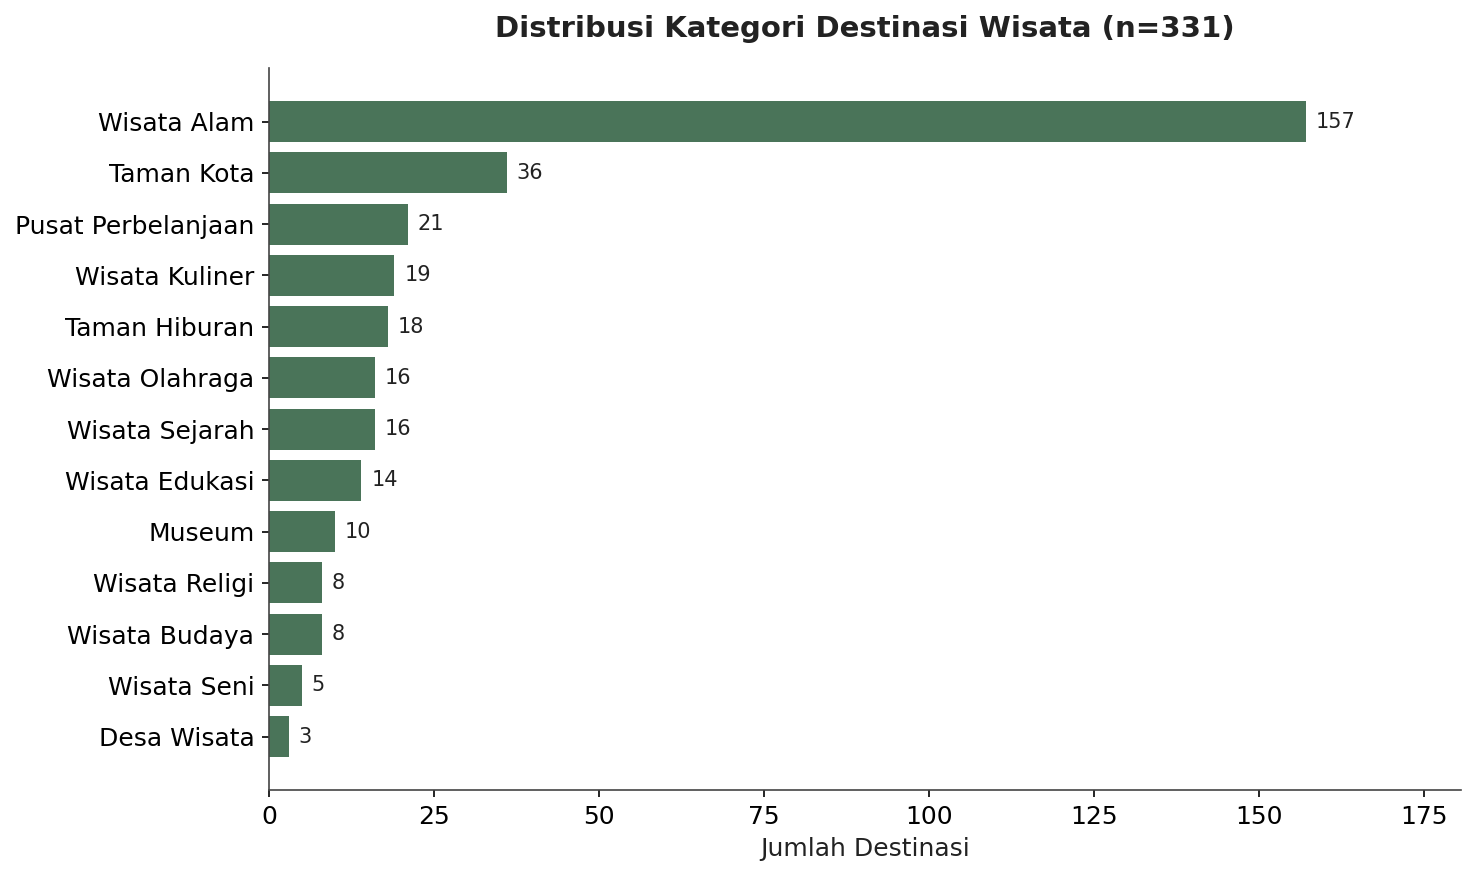

Tersimpan: ..\docs\distribusi_kategori.png


In [35]:
# ============================================================
# GAMBAR 1: Distribusi Kategori
# ============================================================
cat_counts = df['Category'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
bars = ax.barh(cat_counts.index, cat_counts.values, color=FOREST_3)
for bar, val in zip(bars, cat_counts.values):
    ax.text(val + 1.5, bar.get_y() + bar.get_height()/2, str(val),
            va='center', fontsize=10)
ax.set_xlabel('Jumlah Destinasi')
ax.set_title(f'Distribusi Kategori Destinasi Wisata (n={len(df)})',
             fontsize=14, fontweight='bold', pad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, cat_counts.max() * 1.15)
plt.tight_layout()
plt.savefig(docs_dir / 'distribusi_kategori.png', facecolor='white')
plt.show()
print('Tersimpan:', docs_dir / 'distribusi_kategori.png')


### 11.2 Distribusi Destinasi Berdasarkan Wilayah

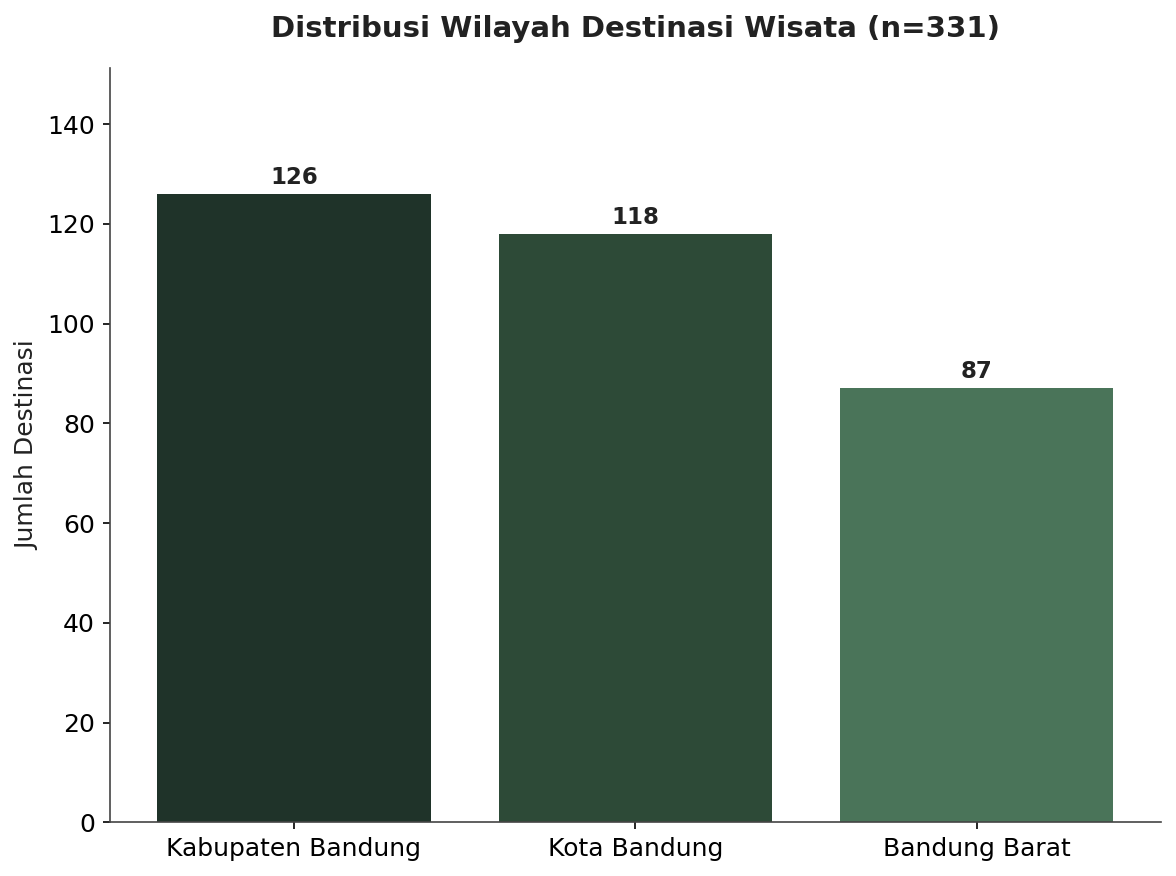

Tersimpan: ..\docs\distribusi_wilayah.png


In [36]:
# ============================================================
# GAMBAR 2: Distribusi Wilayah
# ============================================================
city_counts = df['City'].value_counts()

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
colors = [FOREST, FOREST_2, FOREST_3]
bars = ax.bar(city_counts.index, city_counts.values, color=colors[:len(city_counts)])
for bar, val in zip(bars, city_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 2, str(val),
            ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Jumlah Destinasi')
ax.set_title(f'Distribusi Wilayah Destinasi Wisata (n={len(df)})',
             fontsize=14, fontweight='bold', pad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, city_counts.max() * 1.2)
plt.tight_layout()
plt.savefig(docs_dir / 'distribusi_wilayah.png', facecolor='white')
plt.show()
print('Tersimpan:', docs_dir / 'distribusi_wilayah.png')


### 11.3 Distribusi Panjang Deskripsi Destinasi

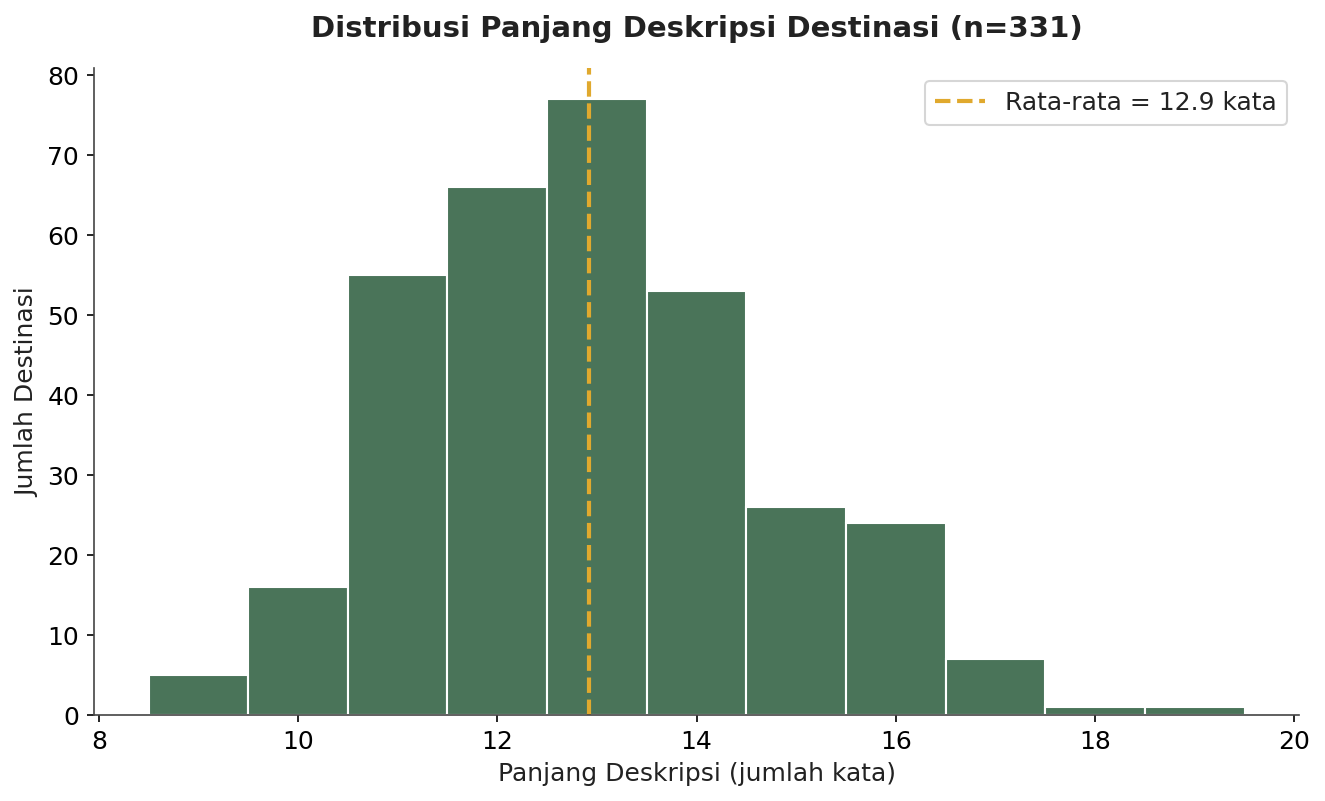

Tersimpan: ..\docs\distribusi_panjang_deskripsi.png


In [37]:
# ============================================================
# GAMBAR 3: Distribusi Panjang Deskripsi
# ============================================================
desc_len = df['Description'].str.split().str.len()

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=150)
ax.hist(desc_len,
        bins=range(int(desc_len.min()), int(desc_len.max()) + 2),
        color=FOREST_3, edgecolor='white', align='left')
ax.axvline(desc_len.mean(), color=GOLD, linestyle='--', linewidth=2,
           label=f'Rata-rata = {desc_len.mean():.1f} kata')
ax.set_xlabel('Panjang Deskripsi (jumlah kata)')
ax.set_ylabel('Jumlah Destinasi')
ax.set_title(f'Distribusi Panjang Deskripsi Destinasi (n={len(df)})',
             fontsize=14, fontweight='bold', pad=15)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(docs_dir / 'distribusi_panjang_deskripsi.png', facecolor='white')
plt.show()
print('Tersimpan:', docs_dir / 'distribusi_panjang_deskripsi.png')


### 11.4 Heatmap Cosine Similarity (Overview 30 Destinasi Acak)

Karena matriks similarity berukuran 331×331 (terlalu besar untuk ditampilkan penuh), diambil sampel 30 destinasi acak dengan `random_state=42` (hasil sampling akan sama setiap kali dijalankan).


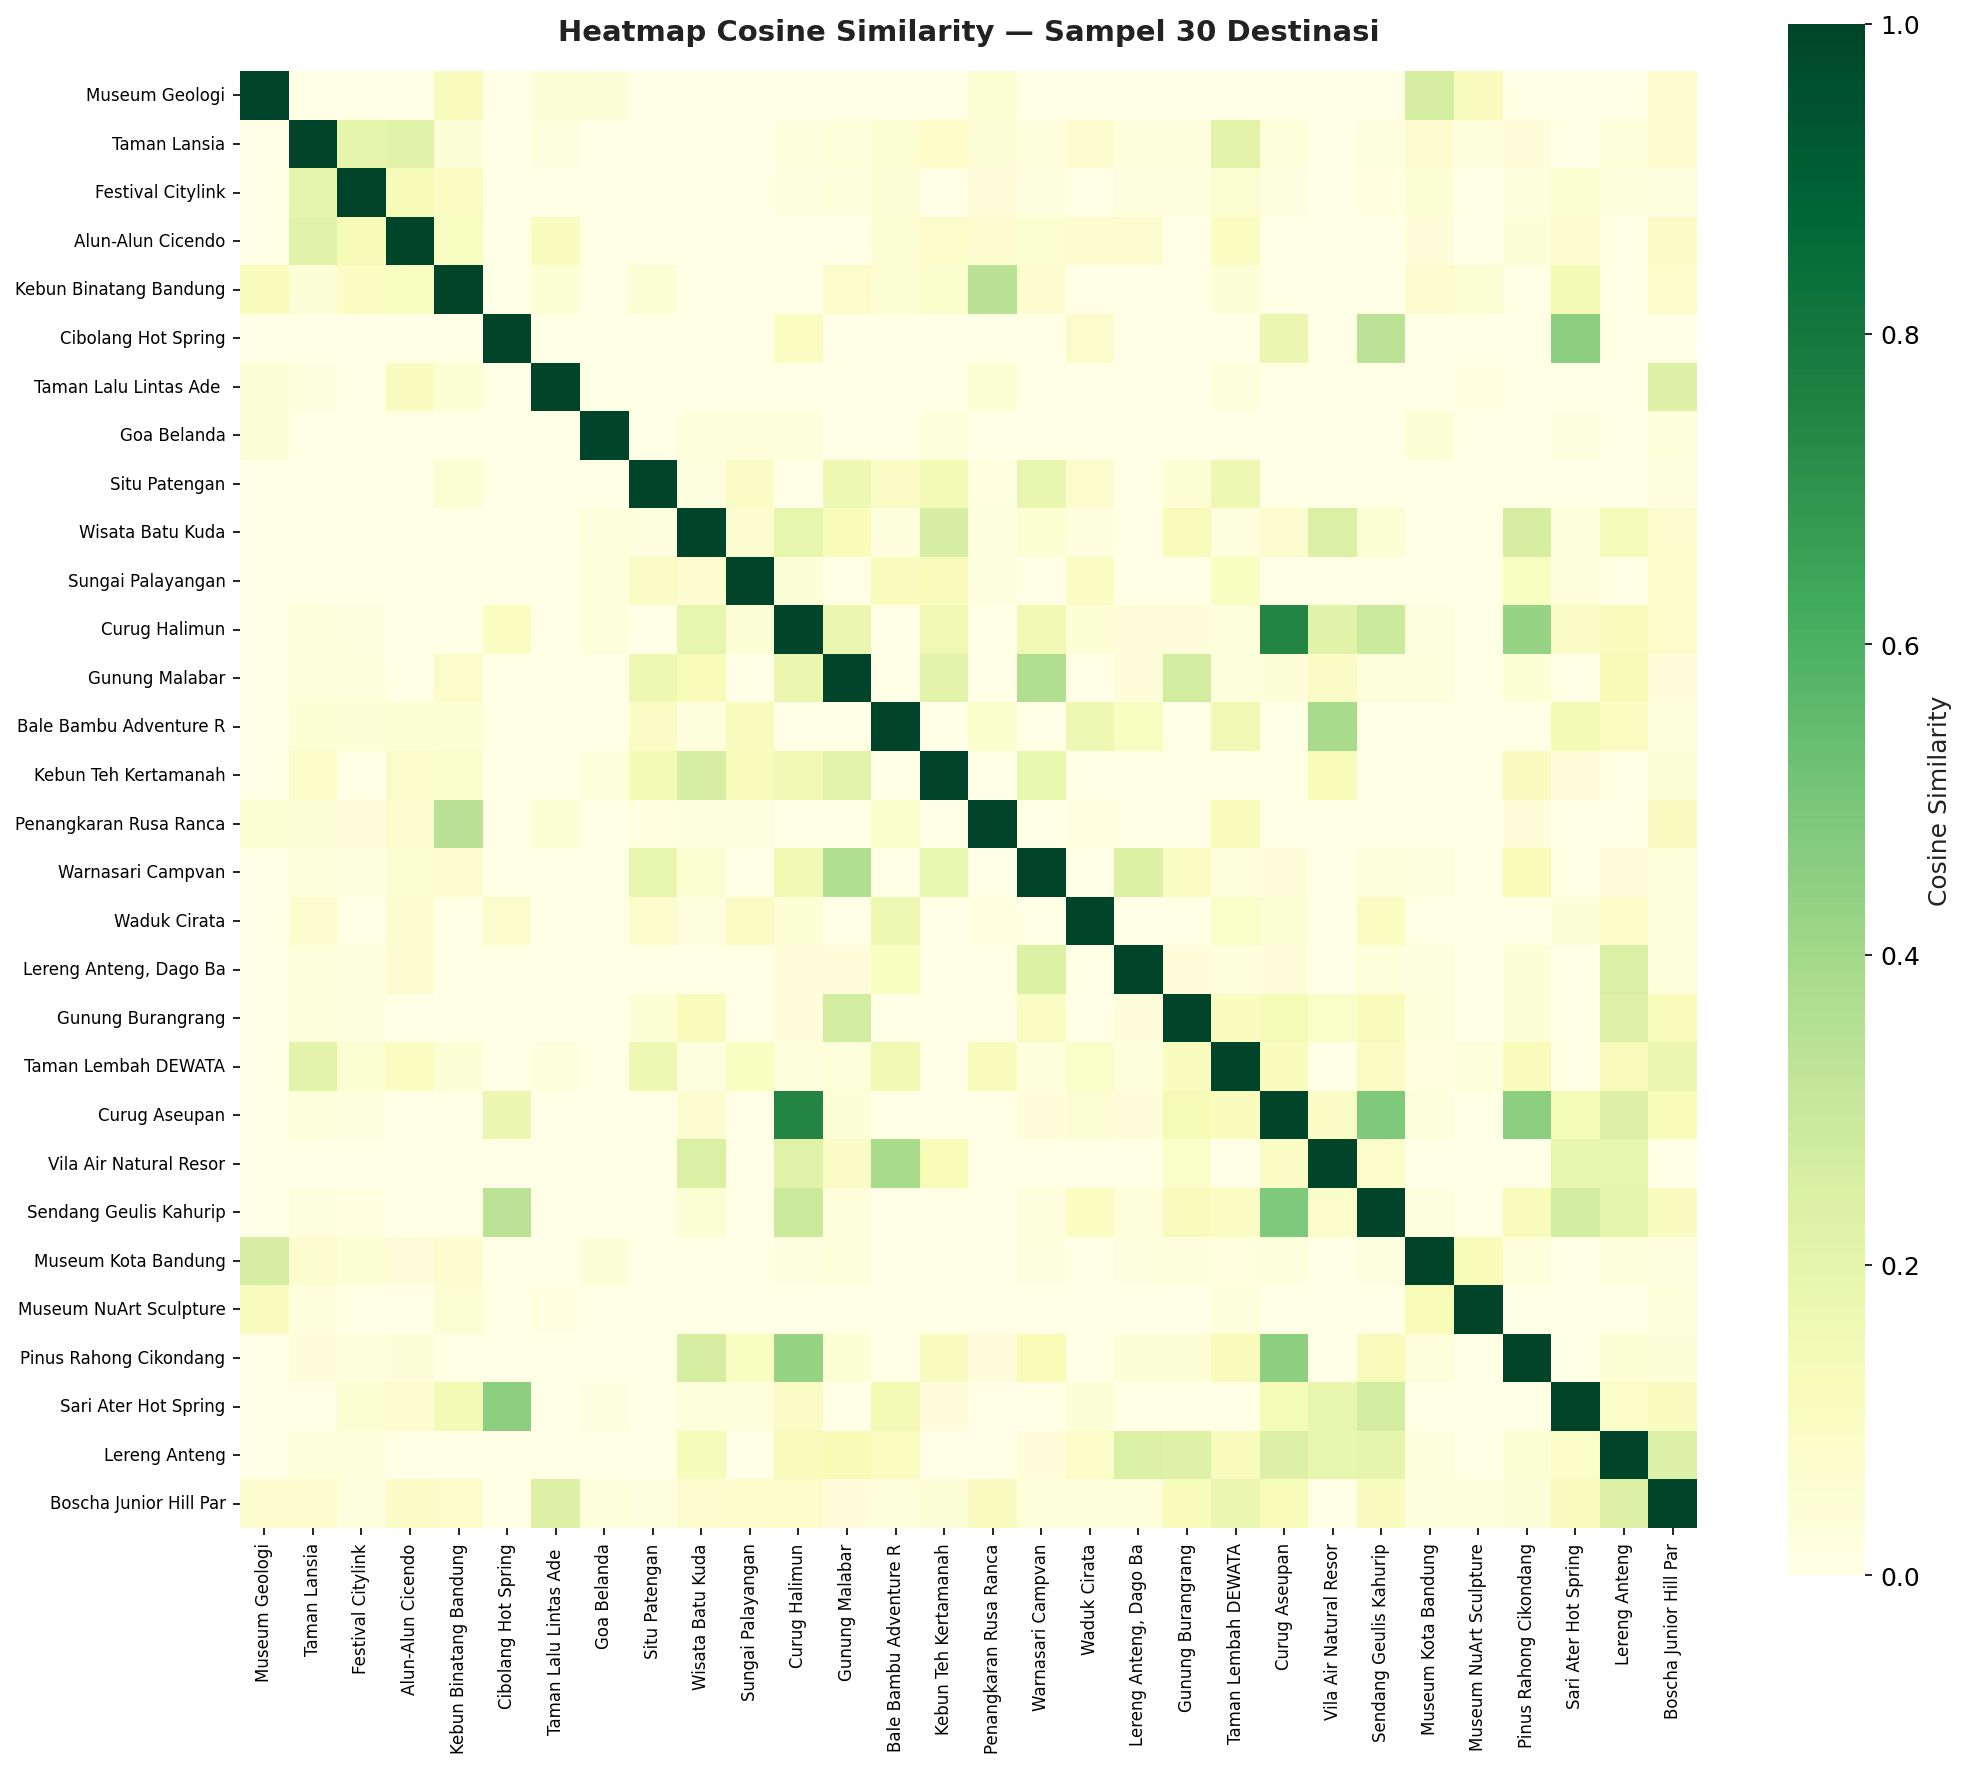

Tersimpan: ..\docs\heatmap_cosine_similarity.png


In [38]:
# ============================================================
# GAMBAR 4: Heatmap Cosine Similarity — 30 Destinasi Acak
# ============================================================
rng = np.random.RandomState(42)
sample_idx = np.sort(rng.choice(len(df), size=30, replace=False))
sample_names = df.iloc[sample_idx]['Place_Name'].str.slice(0, 22).values
sub_matrix = cosine_sim_matrix[np.ix_(sample_idx, sample_idx)]

fig, ax = plt.subplots(figsize=(14, 12), dpi=150)
sns.heatmap(sub_matrix,
            xticklabels=sample_names, yticklabels=sample_names,
            cmap='YlGn', vmin=0, vmax=1, square=True,
            cbar_kws={'label': 'Cosine Similarity'}, ax=ax)
ax.set_title(f'Heatmap Cosine Similarity — Sampel {len(sample_idx)} Destinasi',
             fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(docs_dir / 'heatmap_cosine_similarity.png', facecolor='white')
plt.show()
print('Tersimpan:', docs_dir / 'heatmap_cosine_similarity.png')


### 11.5 Heatmap Similarity — 15 Destinasi Kategori Wisata Alam

Heatmap versi lebih kecil dan beranotasi angka, difokuskan ke 15 destinasi pertama kategori "Wisata Alam" agar polanya lebih mudah dibaca.


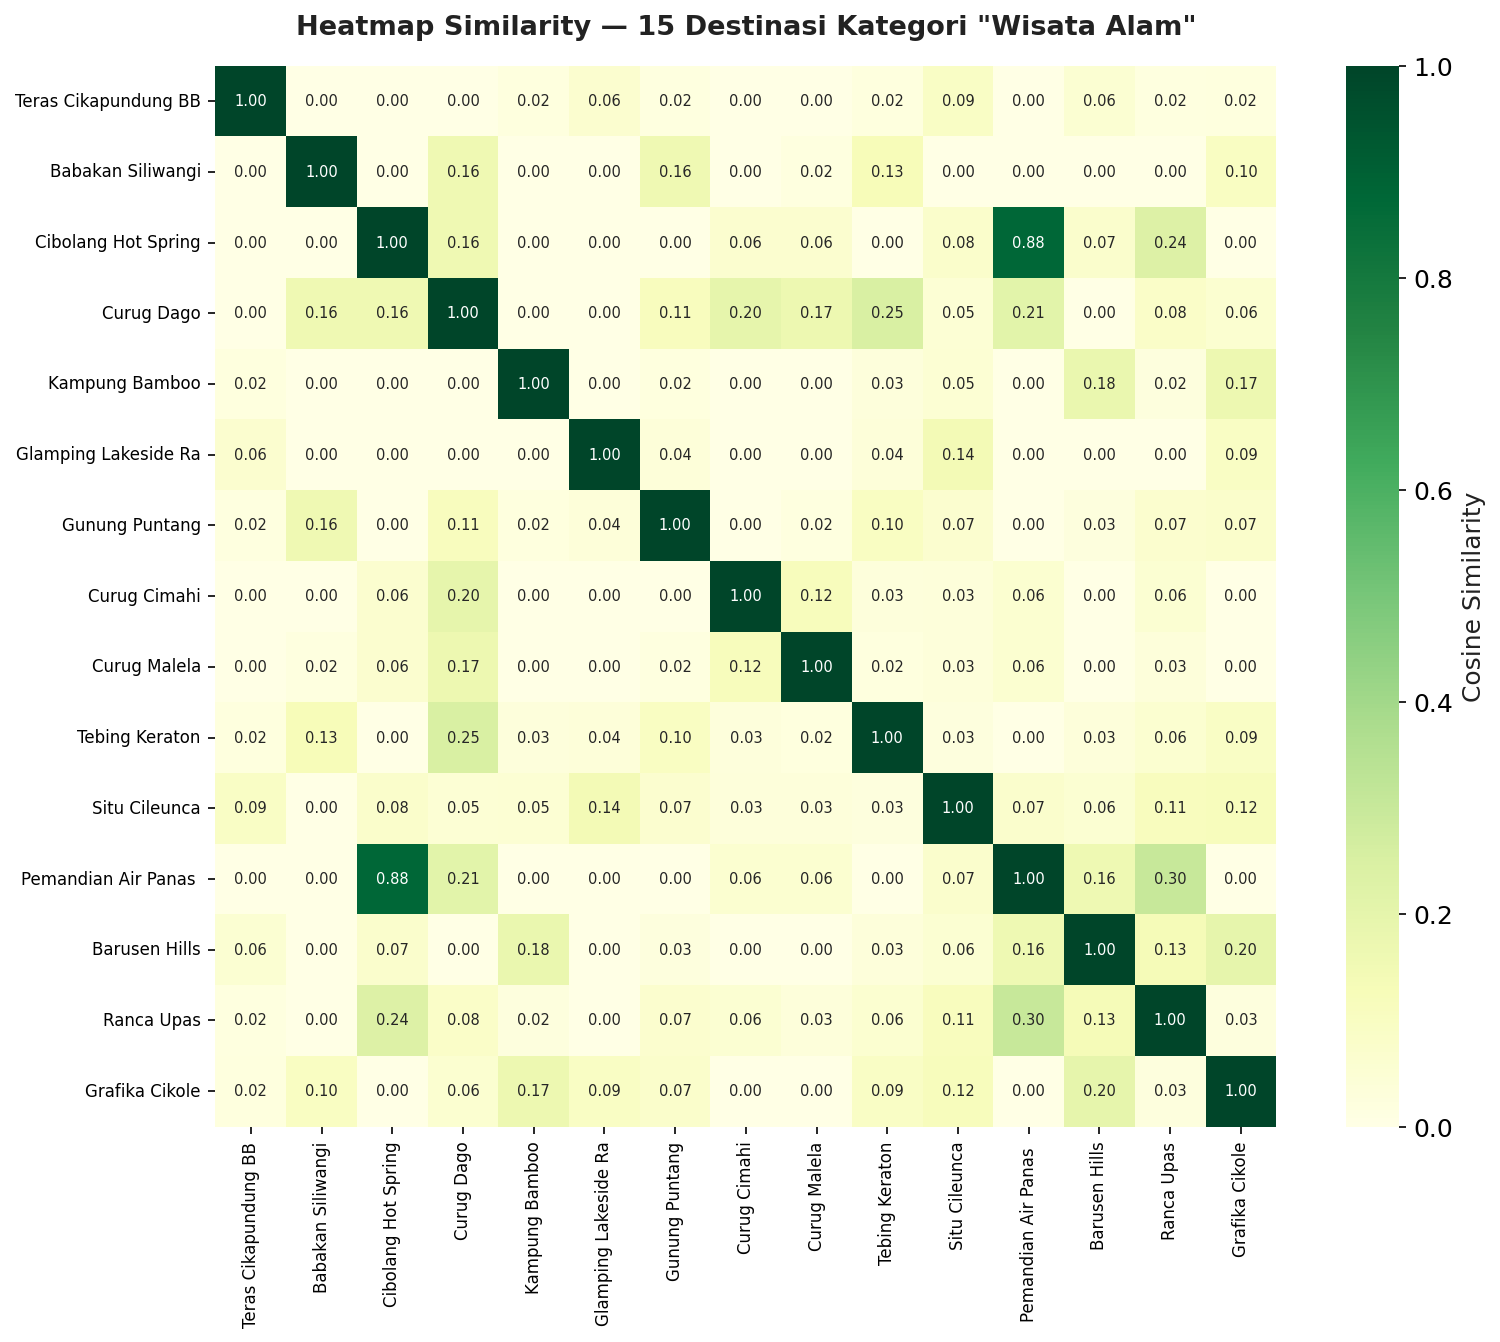

Tersimpan: ..\docs\heatmap_similarity.png


In [39]:
# ============================================================
# GAMBAR 5: Heatmap Similarity — Wisata Alam (Beranotasi)
# ============================================================
alam_idx = df.index[df['Category'] == 'Wisata Alam'].tolist()[:15]
alam_names = df.iloc[alam_idx]['Place_Name'].str.slice(0, 20).values
sub_alam = cosine_sim_matrix[np.ix_(alam_idx, alam_idx)]

fig, ax = plt.subplots(figsize=(11, 9), dpi=150)
sns.heatmap(sub_alam,
            xticklabels=alam_names, yticklabels=alam_names,
            cmap='YlGn', vmin=0, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7},
            square=True, cbar_kws={'label': 'Cosine Similarity'}, ax=ax)
ax.set_title('Heatmap Similarity — 15 Destinasi Kategori "Wisata Alam"',
             fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig(docs_dir / 'heatmap_similarity.png', facecolor='white')
plt.show()
print('Tersimpan:', docs_dir / 'heatmap_similarity.png')


### 11.6 Precision@5 vs Precision@10 per Query

Grafik ini memakai hasil evaluasi (`evaluasi_df`) yang sudah dihitung di Bagian 8.5, jadi angkanya konsisten dengan file `hasil_precision_map.xlsx` di folder output.


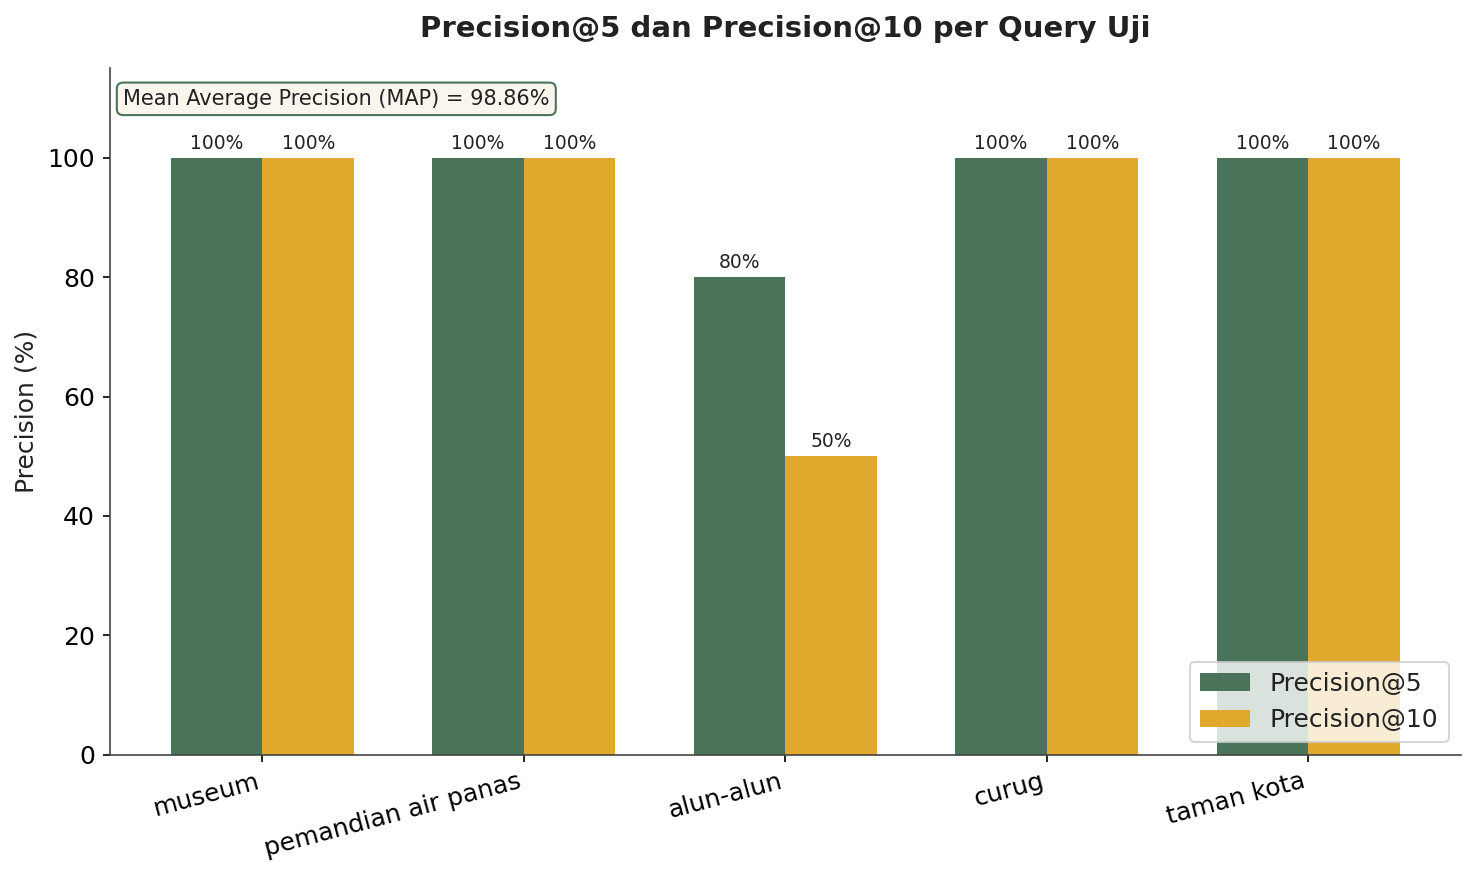

Tersimpan: ..\docs\precision_per_kategori.png
MAP keseluruhan: 98.86%


In [40]:
# ============================================================
# GAMBAR 6: Precision@5 vs Precision@10 per Query
# ============================================================
x = np.arange(len(evaluasi_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6), dpi=150)
b1 = ax.bar(x - width/2, evaluasi_df['Precision@5 (%)'],  width, label='Precision@5',  color=FOREST_3)
b2 = ax.bar(x + width/2, evaluasi_df['Precision@10 (%)'], width, label='Precision@10', color=GOLD)

for bars in (b1, b2):
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 1.5, f'{h:.0f}%',
                ha='center', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(evaluasi_df['Query'], rotation=15, ha='right')
ax.set_ylabel('Precision (%)')
ax.set_ylim(0, 115)
ax.set_title('Precision@5 dan Precision@10 per Query Uji',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='lower right')
ax.spines[['top', 'right']].set_visible(False)

map_percent = evaluasi_df['Average Precision'].mean() * 100
ax.text(0.01, 0.97,
        f'Mean Average Precision (MAP) = {map_percent:.2f}%',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', facecolor='#faf6ee', edgecolor=FOREST_3))

plt.tight_layout()
plt.savefig(docs_dir / 'precision_per_kategori.png', facecolor='white')
plt.show()
print('Tersimpan:', docs_dir / 'precision_per_kategori.png')
print(f'MAP keseluruhan: {map_percent:.2f}%')


### 11.7 Verifikasi Semua Gambar Tersimpan

In [41]:
# Verifikasi semua gambar tersimpan di folder docs
print('=== FILE DI FOLDER DOCS ===')
for filename in sorted(os.listdir(docs_dir)):
    if filename.endswith('.png'):
        filepath = docs_dir / filename
        size_kb = os.path.getsize(filepath) / 1024
        print(f'  {filename:40s} ({size_kb:.1f} KB)')
print('\nSemua visualisasi selesai dibuat.')


=== FILE DI FOLDER DOCS ===
  distribusi_kategori.png                  (68.7 KB)
  distribusi_panjang_deskripsi.png         (43.2 KB)
  distribusi_wilayah.png                   (39.3 KB)
  heatmap_cosine_similarity.png            (195.2 KB)
  heatmap_similarity.png                   (197.2 KB)
  precision_per_kategori.png               (70.7 KB)

Semua visualisasi selesai dibuat.
